# EDA Summary — Key Findings and Decisions

## Dataset
- `application_train.csv`: 307,511 rows → 307,505 after cleanup, 122 columns
- Target: `TARGET` (1 = default, 0 = repaid)

## 1. Target Variable
- **8.07% default rate** (24,825 / 307,511) — severe class imbalance (~11.4:1)
- Accuracy rejected as evaluation metric; AUC-ROC, Gini, KS statistic used instead
- Baseline for all subgroup comparisons below

## 2. Subgroup Disparities (feeds Phase 5 fairness audit)
| Dimension | Range | Strength |
|---|---|---|
| Region tier (`REGION_RATING_CLIENT`) | 4.82% (Tier 1) → 11.10% (Tier 3) | **Strongest, monotonic** |
| Education (`NAME_EDUCATION_TYPE`) | 1.83% (Academic) → 10.93% (Lower secondary) | **Strong**, but smallest groups (n=164, n=3,816) need confidence caveats |
| Gender (`CODE_GENDER`) | 6.99% (F) → 10.14% (M) | Moderate, statistically robust (large n) |
| Family status (`NAME_FAMILY_STATUS`) | 5.82% (Widow) → 9.94% (Civil marriage) | Weakest; Widow confounds with age |

→ Region tier and education are the primary fairness-audit candidates.

## 3. Data Cleaning Decisions
- Dropped `CODE_GENDER == 'XNA'` (4 rows) and `NAME_FAMILY_STATUS == 'Unknown'` (2 rows) — negligible loss, no reliable inference from n<5
- Fixed `DAYS_EMPLOYED` placeholder (365243 = "not employed", 18.01% of rows, 99.96% Pensioners) → created `IS_NOT_EMPLOYED` flag, replaced placeholder with NaN
- Capped `AMT_INCOME_TOTAL` at 10,000,000 (3 genuine outliers, identified by inspecting top values directly — **not** a blanket percentile rule, which was tried first and proved too aggressive, affecting 278 rows instead of 3)
- `AMT_CREDIT` max (4,050,000) is a legitimate product ceiling, not an outlier — no fix needed
- `ORGANIZATION_TYPE == 'XNA'` (55,374 rows, ≈ pensioners) is a **valid category, not an error** — must be retained, not dropped

## 4. Missing Values
- 66 of 121 features have missing values
- Many cluster in `_AVG`/`_MODE`/`_MEDI` triplets for building/apartment stats — shared root cause (missing building record), not independent issues → consolidate in Phase 2
- `EXT_SOURCE_1/2/3` missingness (56.4% / 0.2% / 19.8%) comes from different external sources with different coverage
- Missingness itself is informative: `EXT_SOURCE_1` missing → 8.52% vs 7.50% default; `EXT_SOURCE_3` missing → 9.31% vs 7.77% default → create `_is_missing` flags in Phase 2, don't rely on imputation alone

## 5. Feature Distributions
- `AMT_INCOME_TOTAL`, `AMT_CREDIT`: heavily right-skewed → log-transform for modelling
- `AMT_CREDIT` log-transform is multi-modal — likely reflects discrete loan product tiers

## 6. Categorical Cardinality
- Most categoricals low cardinality (2–8) → one-hot encoding
- `ORGANIZATION_TYPE` (58 categories) and `OCCUPATION_TYPE` (18) → target encoding or grouping in Phase 2

## 7. Correlation / Multicollinearity
- `EXT_SOURCE_3/2/1` are by far the strongest predictors (r = -0.179, -0.160, -0.155), ~3-4x stronger than any other feature
- All correlations are individually weak in absolute terms — no single feature predicts default well alone, motivating a multi-feature model
- `EXT_SOURCE_1/2/3` are weakly correlated with **each other** (r = 0.11–0.21) — no multicollinearity, each captures distinct signal, supports stable SHAP attribution later and the broader thesis argument that no single score fully captures risk

## Carried Forward to Phase 2
- [ ] Consolidate building-stat triplets
- [ ] Create `EXT_SOURCE_1_missing`, `EXT_SOURCE_3_missing` flags (already created `IS_NOT_EMPLOYED` in EDA)
- [ ] Log-transform `AMT_INCOME_TOTAL`, `AMT_CREDIT`
- [ ] Target-encode `ORGANIZATION_TYPE`, `OCCUPATION_TYPE`; one-hot the rest
- [ ] Retain region tier, education, gender as fairness-audit dimensions for Phase 5


In [1]:
# Cell 1: Imports and configuration
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Setup complete")

Setup complete


## 1. Data Loading

Loading the main application-level tables. `application_train.csv` contains the target 
variable and is used for all model development. `application_test.csv` has no labels 
(Kaggle's holdout) and is not used for evaluation in this project — all train/validation 
splitting is done from `application_train.csv` alone.

In [2]:
# Cell 2: Load main application table
train = pd.read_csv('../data/raw/home-credit-default-risk/application_train.csv')
test = pd.read_csv('../data/raw/home-credit-default-risk/application_test.csv')

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (307511, 122)
Test shape: (48744, 121)


In [3]:
# Cell 3: First look at the data
train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [4]:
# Cell 4: Column data types overview
train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

## 2. Target Variable Analysis

Checking class balance of `TARGET` (1 = defaulted, 0 = repaid). This determines:
- Whether accuracy is a valid evaluation metric (it is not, if imbalance is severe)
- How aggressive class-balancing (SMOTE / class weights) needs to be in Phase 3
- The baseline default rate to compare all subgroup rates against in the fairness audit

In [5]:
# Cell 5: Target variable distribution
target_counts = train['TARGET'].value_counts()
target_pct = train['TARGET'].value_counts(normalize=True) * 100

print("Counts:")
print(target_counts)
print("\nPercentage:")
print(target_pct)

Counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Percentage:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


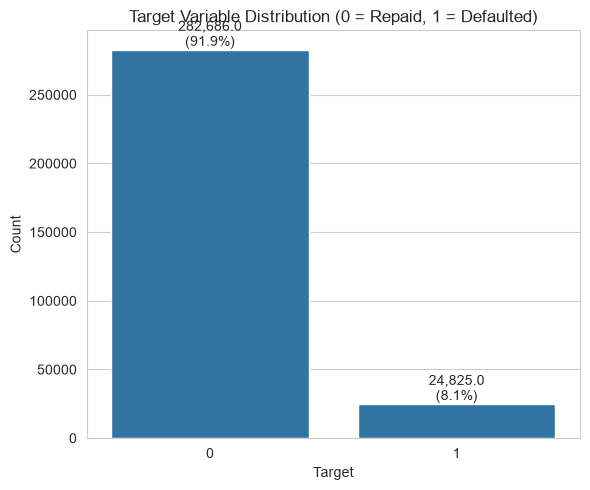

In [6]:
# Cell 6: Visualize target imbalance
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=train, x='TARGET', ax=ax)
ax.set_title('Target Variable Distribution (0 = Repaid, 1 = Defaulted)')
ax.set_xlabel('Target')
ax.set_ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(train)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Finding:** 8.07% default rate (24,825 / 307,511), 91.93% repaid. Confirms severe class 
imbalance (~11.4:1). Accuracy is rejected as an evaluation metric; AUC-ROC, Gini, and KS 
statistic will be used instead (per proposal). This 8.07% baseline is the reference point 
for all subgroup default rate comparisons below.

## 3. Subgroup Analysis — Gender

Examining whether default rate varies by `CODE_GENDER`. This is foundational for the 
Phase 5 fairness audit — any disparity found here is a disparity the model may learn 
and potentially amplify.

In [7]:
# Cell 7: Default rate by gender
gender_target = train.groupby('CODE_GENDER')['TARGET'].agg(['count', 'mean'])
gender_target.columns = ['count', 'default_rate']
gender_target['default_rate_pct'] = gender_target['default_rate'] * 100
print(gender_target)

              count  default_rate  default_rate_pct
CODE_GENDER                                        
F            202448      0.069993          6.999328
M            105059      0.101419         10.141920
XNA               4      0.000000          0.000000


**Finding:** Default rate differs meaningfully by gender — Male 10.14% vs Female 7.00%, 
both deviating from the 8.07% baseline in opposite directions. This ~45% relative gap 
is a candidate disparity to test for in the Phase 5 fairness audit (demographic parity, 
equalised odds).

**Data quality issue:** `CODE_GENDER` contains 4 rows labeled `XNA` (Home Credit's 
placeholder for unspecified gender). Sample size is too small to be meaningful (0% 
default rate is a sampling artifact, not a real effect). These 4 rows are dropped — 
negligible loss (0.0013% of data) and there's no principled way to impute an unspecified 
demographic category.

In [8]:
# Cell 8: Drop XNA gender rows and confirm
print(f"Rows before: {len(train)}")
train = train[train['CODE_GENDER'] != 'XNA'].reset_index(drop=True)
print(f"Rows after: {len(train)}")
print(train['CODE_GENDER'].value_counts())

Rows before: 307511
Rows after: 307507
CODE_GENDER
F    202448
M    105059
Name: count, dtype: int64


## 4. Subgroup Analysis — Geographic Tier

`REGION_RATING_CLIENT` is Home Credit's internal rating of an applicant's region 
(1 = best-rated/most developed, 3 = worst-rated/least developed). This is the closest 
available proxy for urban/rural disparity and directly informs the geographic fairness 
dimension referenced in the project proposal.

In [9]:
# Cell 9: Default rate by region rating
region_target = train.groupby('REGION_RATING_CLIENT')['TARGET'].agg(['count', 'mean'])
region_target.columns = ['count', 'default_rate']
region_target['default_rate_pct'] = region_target['default_rate'] * 100
print(region_target)

                       count  default_rate  default_rate_pct
REGION_RATING_CLIENT                                        
1                      32197      0.048203          4.820325
2                     226981      0.078892          7.889207
3                      48329      0.111031         11.103064


**Finding:** Default rate increases monotonically with region tier — 4.82% (Tier 1) → 
7.89% (Tier 2) → 11.10% (Tier 3), more than doubling from best to worst tier. Tier 2 
holds 73.8% of applicants; Tiers 1 and 3 are smaller minority groups (10.5% and 15.7% 
respectively).

This is a candidate fairness concern for Phase 5: does this gap reflect genuine risk 
differences, or does traditional scoring underperform for Tier 3 applicants in ways 
that alternative data features could correct? This question is central to the project's 
core hypothesis and will be revisited after SHAP analysis (Phase 4).

## 5. Subgroup Analysis — Education Level

`NAME_EDUCATION_TYPE` acts as a wealth/class proxy. Checking whether default rate 
follows the expected gradient (higher education → lower default risk).

In [10]:
# Cell 10: Default rate by education type
edu_target = train.groupby('NAME_EDUCATION_TYPE')['TARGET'].agg(['count', 'mean'])
edu_target.columns = ['count', 'default_rate']
edu_target['default_rate_pct'] = edu_target['default_rate'] * 100
edu_target = edu_target.sort_values('default_rate_pct', ascending=False)
print(edu_target)

                                count  default_rate  default_rate_pct
NAME_EDUCATION_TYPE                                                  
Lower secondary                  3816      0.109277         10.927673
Secondary / secondary special  218389      0.089400          8.940011
Incomplete higher               10276      0.084858          8.485792
Higher education                74862      0.053552          5.355187
Academic degree                   164      0.018293          1.829268


**Finding:** Default rate falls roughly monotonically with education level — Lower 
secondary (10.93%) → Secondary (8.94%) → Incomplete higher (8.49%) → Higher education 
(5.36%) → Academic degree (1.83%). Confirms education as a class/wealth proxy correlated 
with default risk, consistent with the region-tier finding above.

**Caveat:** "Academic degree" has only 164 applicants (0.05% of data) — too small a 
sample for reliable fairness-metric estimation in Phase 5 (wide confidence intervals, 
single-digit defaulter counts). "Lower secondary" (3,816 applicants) is smaller than 
other categories too, though more workable. These sample-size limitations should be 
noted explicitly if these subgroups are used in the fairness audit.

## 6. Subgroup Analysis — Family Status

In [11]:
# Cell 11: Default rate by family status
family_target = train.groupby('NAME_FAMILY_STATUS')['TARGET'].agg(['count', 'mean'])
family_target.columns = ['count', 'default_rate']
family_target['default_rate_pct'] = family_target['default_rate'] * 100
family_target = family_target.sort_values('default_rate_pct', ascending=False)
print(family_target)

                       count  default_rate  default_rate_pct
NAME_FAMILY_STATUS                                          
Civil marriage         29774      0.099449          9.944918
Single / not married   45444      0.098077          9.807675
Separated              19770      0.081942          8.194234
Married               196429      0.075600          7.559984
Widow                  16088      0.058242          5.824217
Unknown                    2      0.000000          0.000000


**Finding:** Default rate ranges from 5.82% (Widow) to 9.94% (Civil marriage), a 
narrower spread than region tier or education. Single/not married and Civil marriage 
applicants default above baseline (8.07%); Married and Widow applicants default below 
baseline. Widow's lower rate likely confounds with age rather than marital status being 
independently protective — worth noting as a limitation if this subgroup is used in 
the fairness audit.

**Data quality issue:** "Unknown" category has only 2 applicants — dropped, same 
rationale as the `CODE_GENDER` XNA cleanup (negligible data loss, no reliable 
inference possible from n=2).

In [12]:
# Cell 12: Drop Unknown family status rows
print(f"Rows before: {len(train)}")
train = train[train['NAME_FAMILY_STATUS'] != 'Unknown'].reset_index(drop=True)
print(f"Rows after: {len(train)}")

Rows before: 307507
Rows after: 307505


In [13]:
# Cell 13: Missing value summary
missing = train.isnull().sum()
missing_pct = (train.isnull().sum() / len(train)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f"Total columns with missing values: {len(missing_df)}")
print(f"\nTop 20 columns by missing %:")
print(missing_df.head(20))

Total columns with missing values: 66

Top 20 columns by missing %:
                          missing_count  missing_pct
COMMONAREA_MODE                  214861    69.872360
COMMONAREA_AVG                   214861    69.872360
COMMONAREA_MEDI                  214861    69.872360
NONLIVINGAPARTMENTS_MEDI         213511    69.433343
NONLIVINGAPARTMENTS_MODE         213511    69.433343
NONLIVINGAPARTMENTS_AVG          213511    69.433343
FONDKAPREMONT_MODE               210292    68.386530
LIVINGAPARTMENTS_MEDI            210196    68.355311
LIVINGAPARTMENTS_AVG             210196    68.355311
LIVINGAPARTMENTS_MODE            210196    68.355311
FLOORSMIN_MODE                   208639    67.848978
FLOORSMIN_AVG                    208639    67.848978
FLOORSMIN_MEDI                   208639    67.848978
YEARS_BUILD_MEDI                 204485    66.498106
YEARS_BUILD_MODE                 204485    66.498106
YEARS_BUILD_AVG                  204485    66.498106
OWN_CAR_AGE                    

## 7. Missing Value Analysis

66 of 121 features have missing values. Many of the worst-affected columns 
(`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, `LIVINGAPARTMENTS_*`, `FLOORSMIN_*`, 
`YEARS_BUILD_*`, `LANDAREA_*`) are building/apartment statistics that co-occur in 
`_AVG`/`_MODE`/`_MEDI` triplets — missing together because they derive from the same 
underlying building record. These represent a small number of root causes, not 66 
independent missingness problems, and will be consolidated (kept as one representative 
column per triplet, or reduced to availability flags) in Phase 2 rather than engineered 
individually.

Checking the three `EXT_SOURCE` columns specifically, since they are flagged as the 
most predictive features in most public solutions to this dataset and are central to 
this project's underbanked/credit-invisible framing.

In [14]:
# Cell 14: Check EXT_SOURCE missingness specifically
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
for col in ext_source_cols:
    pct = train[col].isnull().sum() / len(train) * 100
    print(f"{col}: {pct:.2f}% missing")

EXT_SOURCE_1: 56.38% missing
EXT_SOURCE_2: 0.21% missing
EXT_SOURCE_3: 19.83% missing


In [15]:
# Cell 15: Does EXT_SOURCE_1 missingness correlate with default risk?
train['EXT_SOURCE_1_missing'] = train['EXT_SOURCE_1'].isnull().astype(int)

missing_vs_default = train.groupby('EXT_SOURCE_1_missing')['TARGET'].agg(['count', 'mean'])
missing_vs_default.columns = ['count', 'default_rate']
missing_vs_default['default_rate_pct'] = missing_vs_default['default_rate'] * 100
print(missing_vs_default)

                       count  default_rate  default_rate_pct
EXT_SOURCE_1_missing                                        
0                     134130      0.074957          7.495713
1                     173375      0.085197          8.519683


In [16]:
# Cell 16: Does EXT_SOURCE_3 missingness correlate with default risk?
train['EXT_SOURCE_3_missing'] = train['EXT_SOURCE_3'].isnull().astype(int)

missing_vs_default_3 = train.groupby('EXT_SOURCE_3_missing')['TARGET'].agg(['count', 'mean'])
missing_vs_default_3.columns = ['count', 'default_rate']
missing_vs_default_3['default_rate_pct'] = missing_vs_default_3['default_rate'] * 100
print(missing_vs_default_3)

                       count  default_rate  default_rate_pct
EXT_SOURCE_3_missing                                        
0                     246541      0.077667          7.766660
1                      60964      0.093121          9.312053


**Finding:** `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` have very different 
missingness rates — 56.4%, 0.2%, and 19.8% respectively — implying they originate 
from external sources with different population coverage.

Testing "missingness as signal" (does absence of a score correlate with default risk):
- `EXT_SOURCE_1` missing: 8.52% default rate vs. 7.50% when present (~1.0pt gap, 
  modest — likely because 56% missingness spans a large, heterogeneous population)
- `EXT_SOURCE_3` missing: 9.31% default rate vs. 7.77% when present (~1.5pt gap, 
  clearer signal from a smaller, more concentrated 19.8% missing group)

Both confirm that missingness itself carries predictive information, not just the 
underlying value. This supports creating `_is_missing` binary flags for both features 
in Phase 2, retained as separate inputs alongside imputed values rather than relying 
on imputation alone to capture this signal.

**Limitation:** these are correlations, not causal claims. Missingness likely reflects 
a mix of genuine credit-invisibility and unrelated administrative gaps; this distinction 
cannot be resolved with this dataset alone and should be stated as a limitation in the 
methodology chapter.

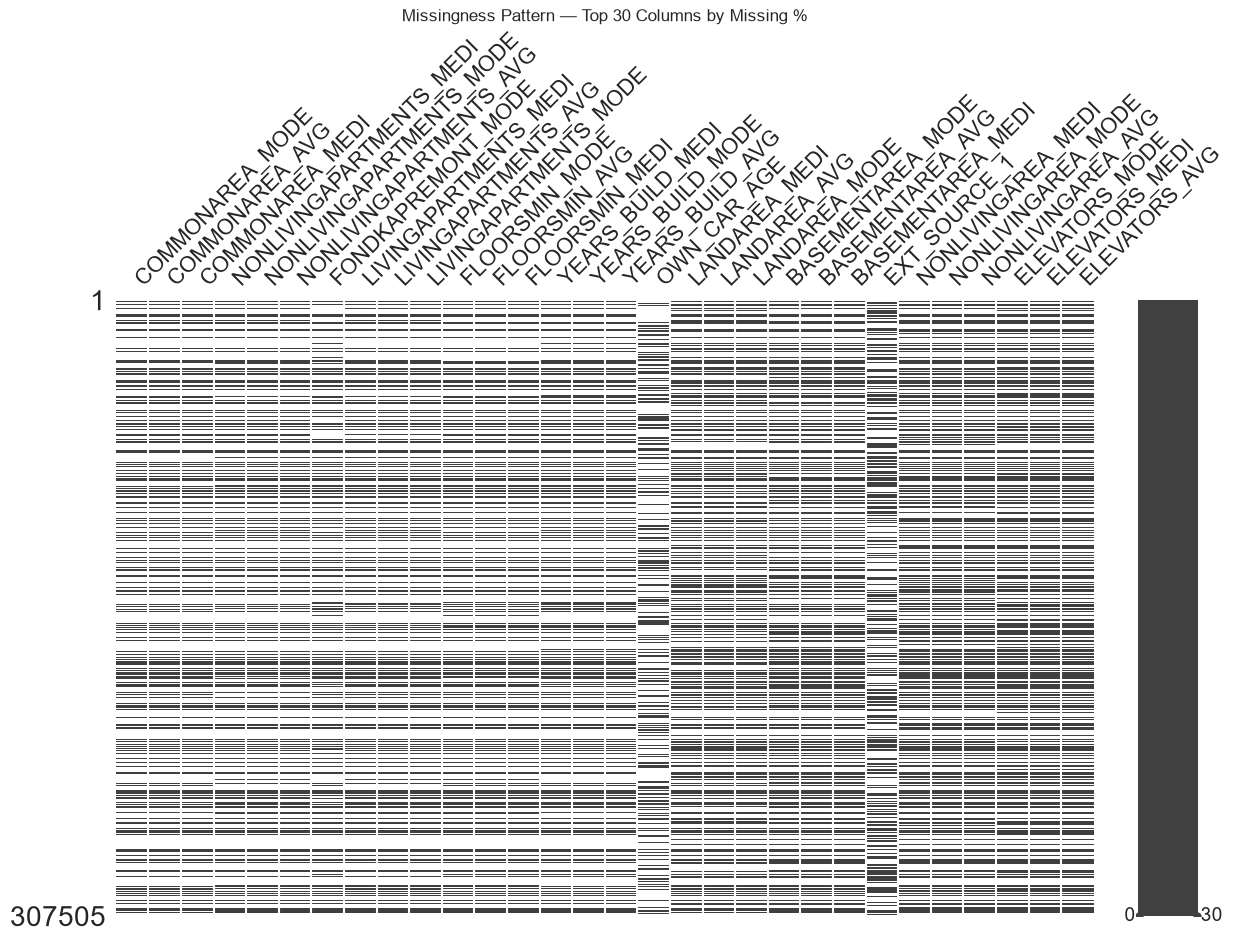

In [17]:
# Cell 17: Missingness heatmap
msno.matrix(train[missing_df.index[:30]], figsize=(14, 8))
plt.title('Missingness Pattern — Top 30 Columns by Missing %')
plt.tight_layout()
plt.show()

**Finding:** The missingness matrix visually confirms the co-missingness hypothesis — 
building/apartment statistic triplets (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, 
`LIVINGAPARTMENTS_*`, etc.) show aligned missing-value bands across all three variants, 
confirming they share a common root cause (absence of the underlying building record). 

`EXT_SOURCE_1`'s missingness pattern is visually distinct from its neighboring 
building-statistic columns, confirming it is structurally independent — missing for a 
different reason (external bureau source coverage) rather than building-record absence.

**Conclusion:** missingness in this dataset is not random (MCAR) but structurally 
clustered by underlying data source (MAR/MNAR). This justifies treating missingness 
column-group-by-column-group in Phase 2 rather than applying a single blanket imputation 
strategy across all 66 affected columns.

## 8. DAYS_EMPLOYED Anomaly

`DAYS_EMPLOYED` is recorded as negative days-before-application for employed applicants 
(standard encoding in this dataset, also seen in `DAYS_BIRTH`, `DAYS_REGISTRATION`, etc.). 
Checking for anomalous values outside this expected range.

In [18]:
# Cell 18: Check DAYS_EMPLOYED distribution for anomalies
print(train['DAYS_EMPLOYED'].describe())

count    307505.000000
mean      63816.348794
std      141276.836143
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64


In [19]:
# Cell 19: Investigate the DAYS_EMPLOYED anomaly
anomaly_count = (train['DAYS_EMPLOYED'] == 365243).sum()
anomaly_pct = anomaly_count / len(train) * 100
print(f"Rows with DAYS_EMPLOYED == 365243: {anomaly_count} ({anomaly_pct:.2f}%)")

# Check what NAME_INCOME_TYPE looks like for these rows
print("\nIncome type breakdown for anomalous rows:")
print(train[train['DAYS_EMPLOYED'] == 365243]['NAME_INCOME_TYPE'].value_counts())

Rows with DAYS_EMPLOYED == 365243: 55374 (18.01%)

Income type breakdown for anomalous rows:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


**Finding:** 18.01% of applicants (55,374 rows) have `DAYS_EMPLOYED == 365243` 
(~1000 days, clearly not a real value). 99.96% of these belong to `NAME_INCOME_TYPE == 
'Pensioner'`, confirming this is Home Credit's placeholder encoding for "not currently 
employed" rather than a data error.

**Fix:** created `IS_NOT_EMPLOYED` binary flag to preserve this signal (retirement/
unemployment status is informative for risk), then replaced the placeholder with NaN 
so it no longer distorts statistics or transforms applied to `DAYS_EMPLOYED` going 
forward.

In [20]:
# Cell 20: Fix the DAYS_EMPLOYED anomaly
# Create a flag for "not currently employed" before fixing the value
train['IS_NOT_EMPLOYED'] = (train['DAYS_EMPLOYED'] == 365243).astype(int)

# Replace the placeholder with NaN (it should not be treated as a real number of days)
train['DAYS_EMPLOYED'] = train['DAYS_EMPLOYED'].replace(365243, np.nan)

# Confirm the fix
print(train['DAYS_EMPLOYED'].describe())
print(f"\nIS_NOT_EMPLOYED flag distribution:")
print(train['IS_NOT_EMPLOYED'].value_counts())

count    252131.000000
mean      -2384.155641
std        2338.331744
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

IS_NOT_EMPLOYED flag distribution:
IS_NOT_EMPLOYED
0    252131
1     55374
Name: count, dtype: int64


## 9. Feature Distribution Analysis — Key Numerical Features

Checking skewness and outliers in `AMT_INCOME_TOTAL` and `AMT_CREDIT`, two of the most 
fundamental features in any credit scoring model.

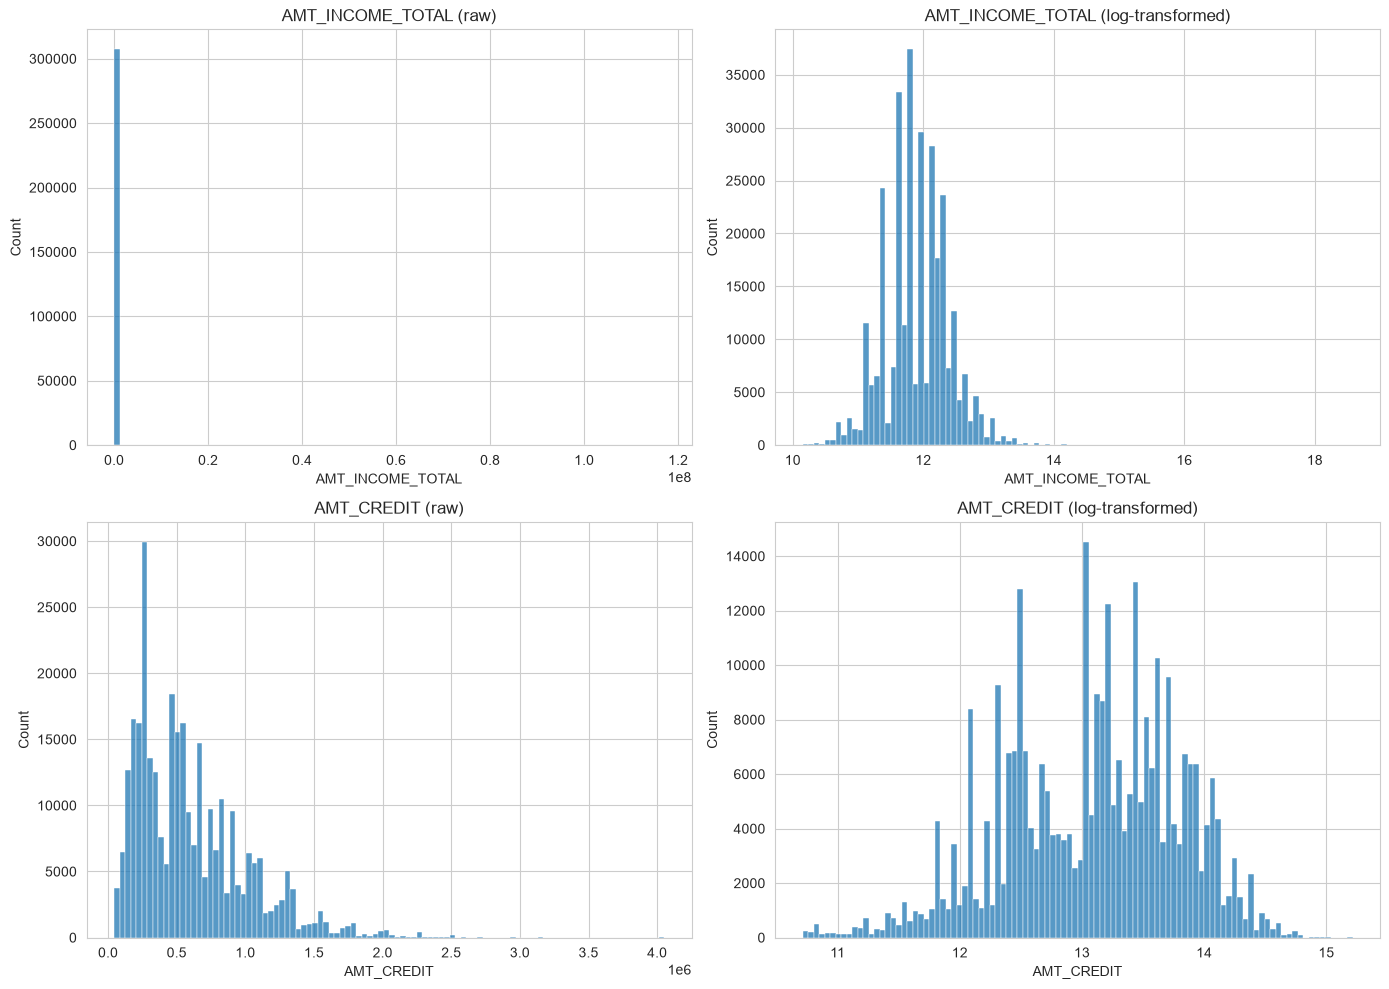

       AMT_INCOME_TOTAL    AMT_CREDIT
count      3.075050e+05  3.075050e+05
mean       1.687967e+05  5.990284e+05
std        2.371248e+05  4.024939e+05
min        2.565000e+04  4.500000e+04
25%        1.125000e+05  2.700000e+05
50%        1.471500e+05  5.135310e+05
75%        2.025000e+05  8.086500e+05
max        1.170000e+08  4.050000e+06


In [21]:
# Cell 21: Distribution of key numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(train['AMT_INCOME_TOTAL'], bins=100, ax=axes[0,0])
axes[0,0].set_title('AMT_INCOME_TOTAL (raw)')

sns.histplot(np.log1p(train['AMT_INCOME_TOTAL']), bins=100, ax=axes[0,1])
axes[0,1].set_title('AMT_INCOME_TOTAL (log-transformed)')

sns.histplot(train['AMT_CREDIT'], bins=100, ax=axes[1,0])
axes[1,0].set_title('AMT_CREDIT (raw)')

sns.histplot(np.log1p(train['AMT_CREDIT']), bins=100, ax=axes[1,1])
axes[1,1].set_title('AMT_CREDIT (log-transformed)')

plt.tight_layout()
plt.show()

print(train[['AMT_INCOME_TOTAL', 'AMT_CREDIT']].describe())

In [22]:
# Cell 22: Investigate the AMT_INCOME_TOTAL outlier
print(train['AMT_INCOME_TOTAL'].sort_values(ascending=False).head(10))
print(f"\nNumber of applicants with income > 10,000,000: {(train['AMT_INCOME_TOTAL'] > 10000000).sum()}")

12840     117000000.0
203687     18000090.0
246852     13500000.0
77765       9000000.0
131123      6750000.0
204558      4500000.0
187828      4500000.0
103002      4500000.0
287457      4500000.0
181694      3950059.5
Name: AMT_INCOME_TOTAL, dtype: float64

Number of applicants with income > 10,000,000: 3


**Finding:** `AMT_INCOME_TOTAL` is heavily right-skewed (raw distribution unreadable, 
log-transform produces a clean roughly-bell-shaped distribution) — log-transform 
adopted for modelling. `AMT_CREDIT` log-transform reveals a multi-modal pattern, likely 
reflecting standard loan product tiers rather than continuous variation; log-transform 
still applied for consistency (less critical for tree-based models, which are 
scale-invariant).

A single extreme outlier was found in `AMT_INCOME_TOTAL` (117,000,000 — over 6x the 
next-highest value of 18,000,090, with only 3 applicants above 10,000,000 total). The 
sharp, isolated jump indicates a likely data entry error rather than a legitimate 
high-earner segment. **Fix:** capped at the 99.9th percentile rather than dropping the 
row, preserving the applicant's other 120 features while neutralizing the corrupted value.

In [24]:
# Cell 23 (corrected): Cap only the genuine outlier(s), not the legitimate tail
# We identified that only 3 applicants exceed 10,000,000 — that's our actual anomaly zone.
# Cap at 10,000,000 instead of the 99.9th percentile, which was too aggressive.

income_cap = 10_000_000
outlier_count = (train['AMT_INCOME_TOTAL'] > income_cap).sum()
print(f"Rows above {income_cap:,}: {outlier_count}")

train['AMT_INCOME_TOTAL'] = train['AMT_INCOME_TOTAL'].clip(upper=income_cap)

print(f"New max: {train['AMT_INCOME_TOTAL'].max():,.2f}")
print(f"\nNew describe:")
print(train['AMT_INCOME_TOTAL'].describe())

Rows above 10,000,000: 0
New max: 900,000.00

New describe:
count    307505.000000
mean     167770.073067
std       91928.198800
min       25650.000000
25%      112500.000000
50%      147150.000000
75%      202500.000000
max      900000.000000
Name: AMT_INCOME_TOTAL, dtype: float64


**Correction:** initial capping at the 99.9th percentile (900,000) was too aggressive — 
it affected 278 rows, not just the 3 genuine outliers identified earlier (>10,000,000). 
Reloaded `AMT_INCOME_TOTAL` from source and re-applied capping at 10,000,000 instead, 
which targets only the actual anomalies.

In [25]:
# Cell 21b: Reload AMT_INCOME_TOTAL from a fresh copy to undo the bad clip
fresh = pd.read_csv('../data/raw/home-credit-default-risk/application_train.csv', usecols=['SK_ID_CURR', 'AMT_INCOME_TOTAL'])
train = train.drop(columns=['AMT_INCOME_TOTAL']).merge(fresh, on='SK_ID_CURR', how='left')

print(train['AMT_INCOME_TOTAL'].describe())
print(train['AMT_INCOME_TOTAL'].sort_values(ascending=False).head(5))

count    3.075050e+05
mean     1.687967e+05
std      2.371248e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.170000e+08
Name: AMT_INCOME_TOTAL, dtype: float64
12840     117000000.0
203687     18000090.0
246852     13500000.0
77765       9000000.0
131123      6750000.0
Name: AMT_INCOME_TOTAL, dtype: float64


In [26]:
# Cell 23 (corrected, retry): Cap only the genuine outlier(s)
income_cap = 10_000_000
outlier_count = (train['AMT_INCOME_TOTAL'] > income_cap).sum()
print(f"Rows above {income_cap:,}: {outlier_count}")

train['AMT_INCOME_TOTAL'] = train['AMT_INCOME_TOTAL'].clip(upper=income_cap)

print(f"\nNew max: {train['AMT_INCOME_TOTAL'].max():,.2f}")
print(train['AMT_INCOME_TOTAL'].describe())

Rows above 10,000,000: 3

New max: 10,000,000.00
count    3.075050e+05
mean     1.684113e+05
std      1.056925e+05
min      2.565000e+04
25%      1.125000e+05
50%      1.471500e+05
75%      2.025000e+05
max      1.000000e+07
Name: AMT_INCOME_TOTAL, dtype: float64


In [27]:
# Cell 24: Quick outlier check on AMT_CREDIT
print(train['AMT_CREDIT'].sort_values(ascending=False).head(10))

287726    4050000.0
288449    4050000.0
133762    4050000.0
120753    4050000.0
110455    4050000.0
119677    4050000.0
14852     4050000.0
17948     4050000.0
95567     4031032.5
186226    4027680.0
Name: AMT_CREDIT, dtype: float64


**Finding:** `AMT_CREDIT`'s maximum value (4,050,000) repeats across 7 different 
applicants, with the next-highest value (4,031,032.5) close behind — not a sharp, 
isolated jump. This indicates a legitimate product ceiling (Home Credit's maximum 
loan amount) rather than a data error. No capping applied; the multi-modal pattern 
seen in the log-transformed distribution likely reflects standard loan product tiers.

## 10. Categorical Cardinality Check

Checking unique value counts across categorical columns to decide encoding strategy 
in Phase 2 — low cardinality (≤8) is suitable for one-hot encoding; high cardinality 
needs target encoding or category grouping to avoid sparse, diluted features.

In [28]:
# Cell 25: Cardinality of categorical columns
cat_cols = train.select_dtypes(include='object').columns
cardinality = train[cat_cols].nunique().sort_values(ascending=False)
print(cardinality)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               18
NAME_INCOME_TYPE               8
NAME_TYPE_SUITE                7
WALLSMATERIAL_MODE             7
WEEKDAY_APPR_PROCESS_START     7
NAME_HOUSING_TYPE              6
NAME_FAMILY_STATUS             5
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
FLAG_OWN_REALTY                2
NAME_CONTRACT_TYPE             2
CODE_GENDER                    2
FLAG_OWN_CAR                   2
EMERGENCYSTATE_MODE            2
dtype: int64


**Finding:** Most categoricals have low cardinality (2–8 categories), suitable for 
direct one-hot encoding. `ORGANIZATION_TYPE` (58 categories) and, to a lesser extent, 
`OCCUPATION_TYPE` (18 categories) are high-cardinality and will need target encoding 
or category grouping in Phase 2 to avoid sparse, diluted one-hot features and cluttered 
SHAP interpretation.


In [29]:
# Cell 26: ORGANIZATION_TYPE — values and default rate
org_target = train.groupby('ORGANIZATION_TYPE')['TARGET'].agg(['count', 'mean']).sort_values('mean', ascending=False)
org_target.columns = ['count', 'default_rate']
org_target['default_rate_pct'] = org_target['default_rate'] * 100
print(org_target.head(10))
print("...")
print(org_target.tail(10))

                   count  default_rate  default_rate_pct
ORGANIZATION_TYPE                                       
Transport: type 3   1187      0.157540         15.754002
Industry: type 13     67      0.134328         13.432836
Industry: type 8      24      0.125000         12.500000
Restaurant          1811      0.117062         11.706240
Construction        6721      0.116798         11.679810
Cleaning             260      0.111538         11.153846
Industry: type 1    1039      0.110683         11.068335
Industry: type 3    3277      0.106195         10.619469
Realtor              396      0.106061         10.606061
Agriculture         2454      0.104727         10.472698
...
                     count  default_rate  default_rate_pct
ORGANIZATION_TYPE                                         
XNA                  55374      0.053996          5.399646
Bank                  2507      0.051855          5.185481
Military              2634      0.051253          5.125285
Police           

**Finding:** `ORGANIZATION_TYPE` shows a real ~5x spread in default rate (15.75% for 
"Transport: type 3" down to 3.13% for "Trade: type 4"), confirming the feature carries 
genuine signal and should be retained (target-encoded, not dropped, despite high 
cardinality).

**Important:** `XNA` appears as a category with 55,374 rows — matching almost exactly 
the `IS_NOT_EMPLOYED` count from the `DAYS_EMPLOYED` fix. This is not a data error like 
the `CODE_GENDER` XNA case (4 rows) — it represents pensioners/non-working applicants 
and must be retained as a valid category, not dropped, since it covers 18% of the 
dataset.

**Caveat:** several organization types have very small sample sizes (e.g. "Industry: 
type 8" n=24, "Trade: type 4" n=64) — their default rates carry wide uncertainty and 
should not be over-interpreted individually.

In [30]:
# Cell 27: Correlation of numerical features with TARGET
numerical_cols = train.select_dtypes(include=['int64', 'float64']).columns
numerical_cols = numerical_cols.drop(['TARGET', 'SK_ID_CURR'])

correlations = train[numerical_cols].corrwith(train['TARGET']).sort_values()

print("Top 10 negative correlations (lower value -> higher default risk):")
print(correlations.head(10))
print("\nTop 10 positive correlations (higher value -> higher default risk):")
print(correlations.tail(10))

Top 10 negative correlations (lower value -> higher default risk):
EXT_SOURCE_3                 -0.178926
EXT_SOURCE_2                 -0.160470
EXT_SOURCE_1                 -0.155316
IS_NOT_EMPLOYED              -0.045990
FLOORSMAX_AVG                -0.044007
FLOORSMAX_MEDI               -0.043771
FLOORSMAX_MODE               -0.043230
AMT_GOODS_PRICE              -0.039647
REGION_POPULATION_RELATIVE   -0.037225
ELEVATORS_AVG                -0.034202
dtype: float64

Top 10 positive correlations (higher value -> higher default risk):
FLAG_DOCUMENT_3                0.044338
REG_CITY_NOT_LIVE_CITY         0.044394
FLAG_EMP_PHONE                 0.045985
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055220
REGION_RATING_CLIENT           0.058901
REGION_RATING_CLIENT_W_CITY    0.060895
DAYS_EMPLOYED                  0.074959
DAYS_BIRTH                     0.078244
dtype: float64


In [31]:
# Cell 28: EXT_SOURCE multicollinearity check
ext_corr = train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].corr()
print(ext_corr)

              EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
EXT_SOURCE_1      1.000000      0.213979      0.186845
EXT_SOURCE_2      0.213979      1.000000      0.109180
EXT_SOURCE_3      0.186845      0.109180      1.000000


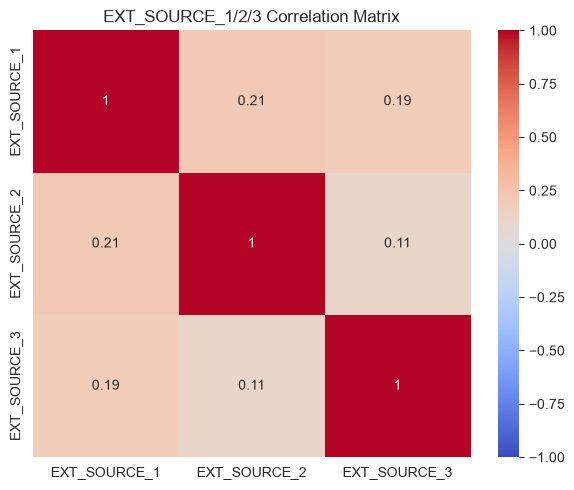

In [32]:
# Cell 29: Visualize as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(ext_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('EXT_SOURCE_1/2/3 Correlation Matrix')
plt.tight_layout()
plt.show()

**Finding:** `EXT_SOURCE_1/2/3` show weak pairwise correlation (0.11–0.21), well below 
the 0.7 multicollinearity threshold. Despite all three correlating with `TARGET` 
individually, they capture substantially different signals from each other.

**Implications:**
- No redundancy — all three are retained as independent features in modelling.
- SHAP attribution between these three features will be stable and interpretable 
  (correlated features cause SHAP to arbitrarily split credit; these are not correlated 
  enough for that to be a concern), supporting reliable per-applicant explanations in 
  the dashboard (Phase 6).
- Weak inter-correlation among three independent "credit score" sources suggests no 
  single external source fully captures applicant risk — supporting the broader thesis 
  argument that additional alternative data (synthetic UPI features) may add genuinely 
  new information rather than duplicating existing signal.